In [1]:
try: 
    import kagglehub #pip install kagglehub
    kagglehub.login()
    path = kagglehub.competition_download('aca-butterflies')
    print("Path to dataset files:", path)
    
except ImportError as e:
    from pathlib import Path
    path = Path().cwd()  / "aca-butterflies"

In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import torch.nn as nn
import torch.utils.data as data
import torchvision.transforms as transforms
import torch.nn.functional as F
from torchvision.transforms import v2
import numpy as np
import copy
import time

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = 224


In [4]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

# First, we read the dataset, preprocess the images and encapsulate them into dataloader form

In [5]:
# load the data
img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

### Train/Test 70/30: Stratified

In [6]:
targets = dataset.img_labels['label'].values 

# Stratified: 70 / 30
train_indices, val_indices = train_test_split(
    range(len(dataset)),
    test_size=0.3,
    stratify=targets,
    random_state=42
)

# DATA AUGMENTATION FOR TRAINING SET
train_transform = v2.Compose([      # ⚠️ ver se aplica de maneira igual a todos as classes
    v2.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(15),
    v2.ToTensor(),
    # v2.Normalize((0.5,), (0.5,))
])

# Subsets
train_dataset = Subset(dataset, train_indices)
train_dataset.dataset = copy.copy(dataset)
train_dataset.dataset.transform = train_transform  # Apply augmentation only to training set
val_dataset = Subset(dataset, val_indices)

# DataLoaders
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Imagens para treino: {len(train_dataset)}")
print(f"Imagens para validação: {len(val_dataset)}")

Imagens para treino: 3639
Imagens para validação: 1560


C:\Users\João Cascais\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [7]:
# VERIFY SAMPLES AND CLASSES
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


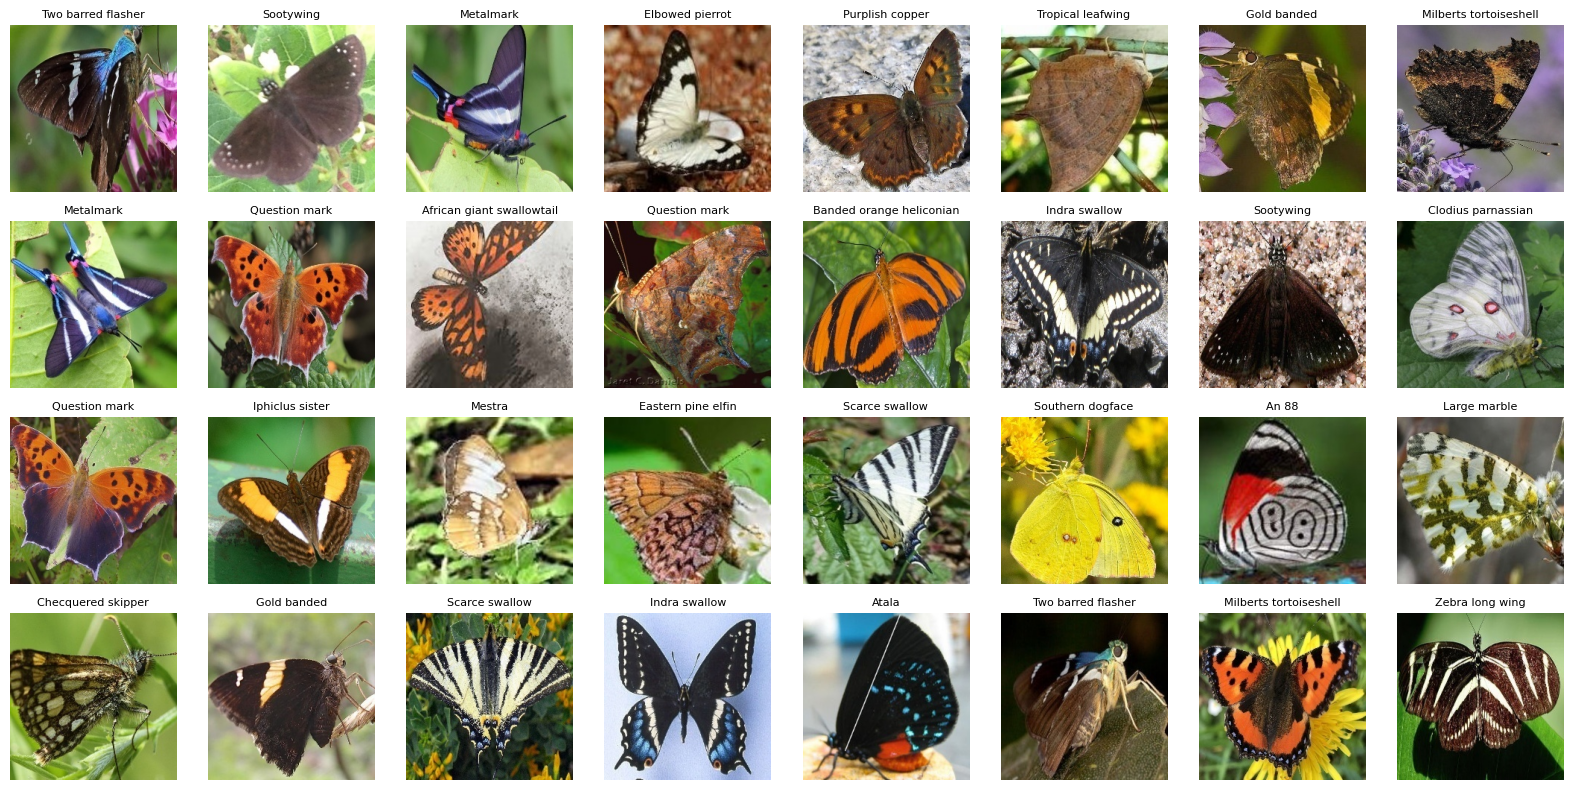

In [8]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(len(images)):
    img = images[i].permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]

    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Data Augmentation

In [ ]:
from torchvision import transforms

# Augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Forth Trial

In [12]:
import torch.nn as nn
import torch.nn.init as init

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, pool_type='max'):
        super(ResidualBlock, self).__init__()
        padding = kernel_size // 2
        
        # Estrutura Pre-Activation: BN -> ReLU -> Conv
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding, bias=False)
        
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, stride=1, padding=padding, bias=False)
        
        # Atalho (Shortcut)
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False)
            
        self.pool = nn.MaxPool2d(2,2) if pool_type == "max" else nn.AvgPool2d(2,2)
        
        # Inicialização Kaiming
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias, 0)

    def forward(self, x):
        # O caminho residual na Pre-Activation começa com BN -> ReLU
        out = self.relu1(self.bn1(x))
        
        # Se o atalho precisar de ajuste, ele usa a versão 'ativada' de x
        shortcut_x = self.shortcut(out) if not isinstance(self.shortcut, nn.Identity) else x
        
        out = self.conv1(out)
        out = self.conv2(self.relu2(self.bn2(out)))
        
        out += shortcut_x
        return self.pool(out)

In [13]:
class ResNet3(nn.Module):
    def __init__(self, config, num_classes=75):
        super(ResNet3, self).__init__()
        c1, c2, c3, c4 = config["channels"]
        k = config["kernel_size"]
        
        # Camada inicial para projetar os 3 canais de entrada
        self.prep = nn.Conv2d(3, c1, kernel_size=3, padding=1, bias=False)
        
        self.block1 = ResidualBlock(c1, c1, k, stride=1, pool_type=config["pool"])
        self.block2 = ResidualBlock(c1, c2, k, stride=config["stride"], pool_type=config["pool"])
        self.block3 = ResidualBlock(c2, c3, k, stride=1, pool_type=config["pool"])
        
        self.block4 = nn.Sequential(
            nn.BatchNorm2d(c3),
            nn.ReLU(),
            nn.Conv2d(c3, c4, k, padding=k//2),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(config["dropout"]),
            nn.Linear(c4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.prep(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.fc(x)
    
# TRAIN + EVAL
def evaluate(model, dataloader, criterion):
    model.eval()
    correct = 0
    total = 0
    loss_total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    loss_avg = loss_total / len(dataloader)
    return acc, loss_avg


# FIT FUNCTION (EARLY STOP + PRUNING)
def fit(model, train_loader, val_loader, optimizer, criterion, trial, epochs=20, patience=5):
    # Inicializar o Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

    train_acc_graph, val_acc_graph = [], []
    train_loss_graph, val_loss_graph = [], []
    time_values = []

    best_val_loss = float("inf")
    best_val_acc = 0
    p = 0

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_acc, _ = evaluate(model, train_loader, criterion)
        val_acc, val_loss = evaluate(model, val_loader, criterion)
        train_loss = total_loss / len(train_loader)

        # Atualizar o Scheduler com base na acurácia de validação
        scheduler.step(val_acc)

        # PRUNING (Optuna)
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            p = 0
        else:
            p += 1

        if p >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        # STORE
        train_acc_graph.append(train_acc * 100)
        val_acc_graph.append(val_acc * 100)
        train_loss_graph.append(train_loss)
        val_loss_graph.append(val_loss)
        time_values.append(time.time() - start_time)

        print(f"[{epoch+1}] Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

    # PLOTS
    plt.figure()
    plt.plot(train_acc_graph, label="Train Acc")
    plt.plot(val_acc_graph, label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.savefig(folder + f"acc_{filename}.png")
    plt.close()

    plt.figure()
    plt.plot(train_loss_graph, label="Train Loss")
    plt.plot(val_loss_graph, label="Val Loss")
    plt.legend()
    plt.title("Loss")
    plt.savefig(folder + f"loss_{filename}.png")
    plt.close()

    df = pd.DataFrame({"train_acc": train_acc_graph, "val_acc": val_acc_graph, "train_loss": train_loss_graph, "val_loss": val_loss_graph, "time": time_values})
    if filename is not None:
        df.to_csv(folder + filename + ".csv", index=True, index_label="epoch")

    
    return best_val_acc, epoch + 1

In [15]:
import optuna

def objective(trial):
    # Dicionários de Loss e Opt (os mesmos que já tens)
    losses = {'CrossEntropy': nn.CrossEntropyLoss, 'MultiMargin': nn.MultiMarginLoss}
    optimizers_dict = {'ADAM': torch.optim.Adam, 'RMS': torch.optim.RMSprop}

    config = {
        "kernel_size": trial.suggest_categorical("kernel_size", [3, 5]),
        "stride": trial.suggest_categorical("stride", [1, 2]),
        "pool": trial.suggest_categorical("pool", ["max", "avg"]),
        "dropout": trial.suggest_float("dropout", 0.2, 0.6),
        "channels": [
            trial.suggest_categorical("c1", [32, 64]),
            trial.suggest_categorical("c2", [64, 128]),
            trial.suggest_categorical("c3", [128, 256]),
            trial.suggest_categorical("c4", [256, 512])
        ],
        "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    }

    # INSTANCIAR A RESNET
    model = ResNet3(config).to(device)

    loss_name = trial.suggest_categorical('loss_fn', list(losses.keys()))
    criterion = losses[loss_name]()
    
    opt_name = trial.suggest_categorical('optimizer', list(optimizers_dict.keys()))
    optimizer = optimizers_dict[opt_name](model.parameters(), lr=config["lr"])

    # RODAR O FIT (A tua função fit atualizada que retorna acc e epochs)
    acc, epochs_used = fit(
        model, train_loader, val_loader, optimizer, criterion, trial,
        epochs=50, patience=10, folder="Results/ResNet/optuna3/", 
        filename=f"resnet_trial_{trial.number}", plot=False
    )

    trial.set_user_attr("epochs_used", epochs_used)
    return acc

# Criar e rodar o estudo
study_resnet = optuna.create_study(
    study_name="ResNet_Optimization_3",
    direction="maximize",
    storage="sqlite:///resnet_study3.db",
    load_if_exists=True
)

study_resnet.optimize(objective, n_trials=20)

[I 2026-04-10 23:34:45,763] Using an existing study with name 'ResNet_Optimization_3' instead of creating a new one.
[W 2026-04-10 23:34:45,917] Trial 1 failed with parameters: {'kernel_size': 3, 'stride': 2, 'pool': 'max', 'dropout': 0.5735986474872448, 'c1': 64, 'c2': 128, 'c3': 128, 'c4': 256, 'lr': 0.00024689705107874474, 'loss_fn': 'CrossEntropy', 'optimizer': 'ADAM'} because of the following error: TypeError("fit() got an unexpected keyword argument 'folder'").
Traceback (most recent call last):
  File "C:\Users\João Cascais\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\João Cascais\AppData\Local\Temp\ipykernel_3024\279609897.py", line 32, in objective
    acc, epochs_used = fit(
                       ^^^^
TypeError: fit() got an unexpected keyword argument 'folder'
[

TypeError: fit() got an unexpected keyword argument 'folder'